In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA 
from sklearn.preprocessing import StandardScaler

In [2]:
HC_adbxd = pd.read_csv('/home/rachel/Desktop/mm-vae data/multiregion_adbxd_cr/HC_adbxd_30perc.csv', low_memory=False)
HC_adbxd = HC_adbxd.iloc[:, 1:]
HC_adbxd

,1,2,3,4,5,6,7,8,9,10,...,subclass,cell_type,SCBID,MouseID,Age,Strain,Genotype,CFM_14_5_snRNA,14-6-residual,14-6-Bin
0,0.809904,0.658327,-0.020847,-0.982691,-1.121771,-0.148075,1.650261,1.503323,-0.099906,1.528749,...,002 IT EP-CLA Glut,glut,CK19059,2433,14,113,5,49.96,-0.111132,2
1,4.540372,-0.333330,1.210636,0.271568,-1.625993,1.295382,-0.037874,1.378154,0.162137,1.313152,...,002 IT EP-CLA Glut,glut,CK19059,2433,14,113,5,49.96,-0.111132,2
2,-1.613538,0.219264,-1.720945,-0.007177,-0.379468,-1.183066,0.403255,-0.715092,0.733725,0.604334,...,002 IT EP-CLA Glut,glut,CK19059,2433,14,113,5,49.96,-0.111132,2
3,0.078730,1.225353,-0.457267,-0.614239,-0.192410,0.414808,-0.079714,-2.275189,1.646772,1.000489,...,002 IT EP-CLA Glut,glut,CK19059,2433,14,113,5,49.96,-0.111132,2
4,-1.110037,0.613995,0.062297,-0.918579,0.686969,-1.272012,-0.143208,0.748415,-0.003739,-1.545116,...,002 IT EP-CLA Glut,glut,CK19059,2433,14,113,5,49.96,-0.111132,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8491,0.157775,-1.288113,-0.384962,-0.379943,0.645772,-0.009342,-1.236780,-1.811799,-1.466269,0.212603,...,334 Microglia NN,Immune,CK19012,1576,14,D2,5,24.44,-0.673075,1
8492,0.118962,-0.541028,-0.557948,-0.724421,-0.196452,-0.294776,-0.539075,0.508162,-0.726167,-0.775506,...,334 Microglia NN,Immune,CK19012,1576,14,D2,5,24.44,-0.673075,1
8493,-0.063253,-0.131895,1.012909,-1.084712,-0.579701,-0.551220,-0.811287,-0.824723,0.436486,-1.012010,...,334 Microglia NN,Immune,CK19012,1576,14,D2,5,24.44,-0.673075,1
8494,-1.240347,-1.802734,1.181334,1.576435,-0.915664,1.803307,-0.355075,1.807765,-1.725267,0.647679,...,335 BAM NN,Immune,CK19012,1576,14,D2,5,24.44,-0.673075,1


In [3]:
pca_hc = PCA().fit(HC_adbxd.iloc[:, :4841])
cumulative_variance_hc = np.cumsum(pca_hc.explained_variance_ratio_)

In [4]:
n_components_90_hc = np.argmax(cumulative_variance_hc >= 0.90) + 1
print(f"Dimensions required for 90% of variance in HC dataset: {n_components_90_hc}")

Dimensions required for 90% of variance in HC dataset: 2624


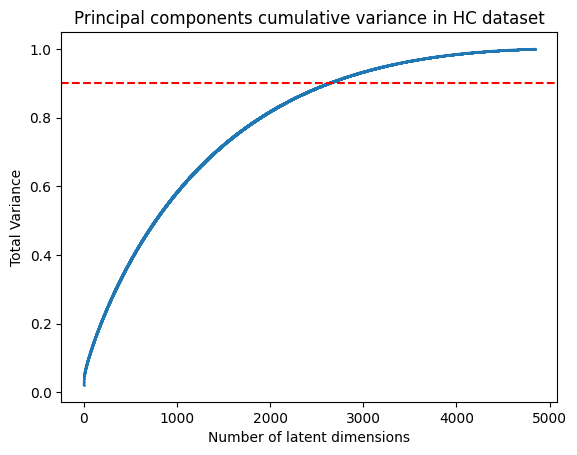

In [12]:
plt.plot(cumulative_variance_hc, marker='o', markersize=1)
plt.axhline(y=0.90, color='r', linestyle='--')
plt.xlabel('Number of latent dimensions')
plt.ylabel('Total Variance')
plt.title('Principal components cumulative variance in HC dataset')
plt.show()

In [14]:
PFC_adbxd = pd.read_csv('/home/rachel/Desktop/mm-vae data/multiregion_adbxd_cr/PFC_adbxd_30perc.csv', low_memory=False)
PFC_adbxd = PFC_adbxd.iloc[:, 1:]
PFC_adbxd

,1,2,3,4,5,6,7,8,9,10,...,subclass,cell_type,SCBID,MouseID,Age,Strain,Genotype,CFM_14_5_snRNA,14-6-residual,14-6-Bin
0,0.339801,-0.917530,-1.389044,-0.913606,0.949042,-1.571387,0.480966,0.485962,0.305117,0.642487,...,001 CLA-EPd-CTX Car3 Glut,Glut,CK19063,2433,14,113,5,49.96,-0.148236,2
1,-1.363207,-0.459285,-2.137615,0.020224,1.266793,0.235777,-0.244888,1.160469,-1.106069,1.154275,...,001 CLA-EPd-CTX Car3 Glut,Glut,CK19063,2433,14,113,5,49.96,-0.148236,2
2,0.317460,-2.141327,1.097311,0.038366,-0.082110,3.568944,0.364516,-0.761616,0.233314,1.838060,...,001 CLA-EPd-CTX Car3 Glut,Glut,CK19063,2433,14,113,5,49.96,-0.148236,2
3,3.354270,0.590532,-2.746669,-0.345913,0.877670,-1.139550,-1.631369,-2.713858,0.443494,-0.944842,...,001 CLA-EPd-CTX Car3 Glut,Glut,CK19063,2433,14,113,5,49.96,-0.148236,2
4,-1.636382,-1.243772,-0.831814,2.465918,3.337233,-0.199536,-3.033197,0.700100,-0.967779,1.162411,...,001 CLA-EPd-CTX Car3 Glut,Glut,CK19063,2433,14,113,5,49.96,-0.148236,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8634,1.286066,-0.354869,-0.650703,0.061316,-1.110073,0.685840,-0.110440,-1.447258,0.346418,-0.156971,...,334 Microglia NN,Immune,CK19106,1576,14,D2,5,24.44,-0.552464,1
8635,0.685799,0.715783,-0.131221,-1.364049,-0.146618,-1.112230,0.130332,-0.456373,-0.013726,0.456758,...,334 Microglia NN,Immune,CK19106,1576,14,D2,5,24.44,-0.552464,1
8636,0.248490,0.971296,1.437387,-0.552479,-0.472411,1.170318,0.098995,-1.099378,-0.501416,-0.775164,...,334 Microglia NN,Immune,CK19106,1576,14,D2,5,24.44,-0.552464,1
8637,0.316272,0.680523,0.325543,-0.551467,0.020069,0.138553,-0.040434,-0.020802,0.615380,-0.416138,...,334 Microglia NN,Immune,CK19106,1576,14,D2,5,24.44,-0.552464,1


In [7]:
pca_pfc = PCA().fit(PFC_adbxd.iloc[:, :4841])
cumulative_variance_pfc = np.cumsum(pca_pfc.explained_variance_ratio_)

In [8]:
n_components_90_pfc = np.argmax(cumulative_variance_pfc >= 0.90) + 1
print(f"Dimensions required for 90% of variance in PFC dataset: {n_components_90_pfc}")

Dimensions required for 90% of variance in PFC dataset: 2595


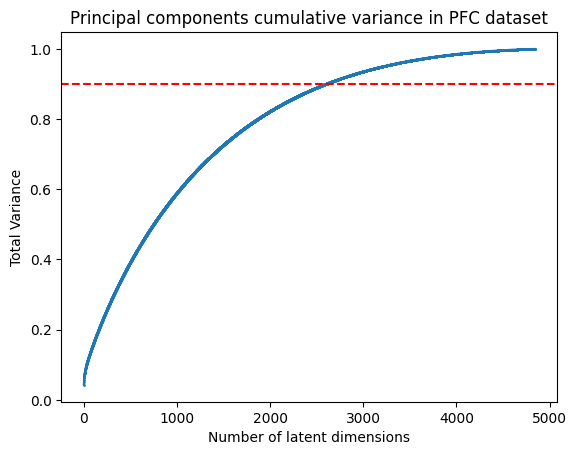

In [13]:
plt.plot(cumulative_variance_pfc, marker='o', markersize=1)
plt.axhline(y=0.90, color='r', linestyle='--')
plt.xlabel('Number of latent dimensions')
plt.ylabel('Total Variance')
plt.title('Principal components cumulative variance in PFC dataset')
plt.show()